#Section 1: Setup and sweep definition

In [1]:
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

assert torch.cuda.is_available(), "Switch Colab to a GPU runtime."
print("PyTorch:", torch.__version__)
print("CUDA via torch:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

device = "cuda"
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.benchmark = True

# (batch, in_features, out_features)
# Chosen to show how TF32 Tensor Core benefit grows with problem size.
SWEEP_CASES = [
    (256, 1024, 1024),
    (1024, 1024, 1024),
    (4096, 1024, 1024),
    (256, 4096, 4096),
    (1024, 4096, 4096),
    (4096, 4096, 4096),
    (256, 8192, 8192),
    (1024, 8192, 8192),
    (2048, 8192, 8192),
]

WARMUP_ITERS = 25

def iterations_for_case(batch, in_features, out_features):
    flops = 2.0 * batch * in_features * out_features
    return 50 if flops >= 2.0 * (1024 ** 3) else 100

def case_label(batch, in_features, out_features):
    return f"B{batch}-K{in_features}-N{out_features}"

name, driver_version, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 580.82.07, 81920 MiB
PyTorch: 2.10.0+cu128
CUDA via torch: 12.8
GPU: NVIDIA A100-SXM4-80GB


#Section 2: PyTorch FC model and benchmark helpers

In [2]:
class FCModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc = nn.Linear(
            in_features,
            out_features,
            bias=False,
            device=device,
            dtype=torch.float32,
        )
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.02)

    def forward(self, x):
        return self.fc(x)

def configure_torch_mode(use_tf32):
    # Baseline: full FP32 path
    # Tensor Core mode: FP32 input/output with TF32 compute allowed
    torch.backends.cuda.matmul.allow_tf32 = use_tf32
    torch.backends.cudnn.allow_tf32 = use_tf32
    torch.set_float32_matmul_precision("high" if use_tf32 else "highest")

@torch.inference_mode()
def benchmark_torch_case(batch, in_features, out_features, use_tf32):
    configure_torch_mode(use_tf32)

    model = FCModel(in_features, out_features).eval()
    x = torch.randn(batch, in_features, device=device, dtype=torch.float32)

    for _ in range(WARMUP_ITERS):
        _ = model(x)
    torch.cuda.synchronize()

    iters = iterations_for_case(batch, in_features, out_features)

    start_event = torch.cuda.Event(enable_timing=True)
    stop_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    for _ in range(iters):
        _ = model(x)
    stop_event.record()
    torch.cuda.synchronize()

    total_ms = start_event.elapsed_time(stop_event)
    avg_ms = total_ms / iters
    tflops = (2.0 * batch * in_features * out_features) / (avg_ms * 1e-3) / 1e12

    return {
        "backend": "PyTorch",
        "mode": "tf32_tensor_core" if use_tf32 else "baseline_fp32",
        "batch": batch,
        "in_features": in_features,
        "out_features": out_features,
        "avg_ms": avg_ms,
        "tflops": tflops,
    }

#Section 3: Run the PyTorch sweep

In [3]:
torch_rows = []

for batch, in_features, out_features in SWEEP_CASES:
    for use_tf32 in [False, True]:
        row = benchmark_torch_case(batch, in_features, out_features, use_tf32)
        torch_rows.append(row)
        print(
            f"[PyTorch] {row['mode']:>16} | "
            f"{case_label(batch, in_features, out_features):>18} | "
            f"{row['avg_ms']:8.3f} ms | {row['tflops']:8.2f} TFLOP/s"
        )

torch_results = pd.DataFrame(torch_rows)
torch_results.to_csv("torch_fc_results.csv", index=False)
torch_results

[PyTorch]    baseline_fp32 |   B256-K1024-N1024 |    0.060 ms |     9.01 TFLOP/s
[PyTorch] tf32_tensor_core |   B256-K1024-N1024 |    0.035 ms |    15.37 TFLOP/s
[PyTorch]    baseline_fp32 |  B1024-K1024-N1024 |    0.160 ms |    13.40 TFLOP/s
[PyTorch] tf32_tensor_core |  B1024-K1024-N1024 |    0.039 ms |    54.53 TFLOP/s
[PyTorch]    baseline_fp32 |  B4096-K1024-N1024 |    0.601 ms |    14.29 TFLOP/s
[PyTorch] tf32_tensor_core |  B4096-K1024-N1024 |    0.108 ms |    79.66 TFLOP/s
[PyTorch]    baseline_fp32 |   B256-K4096-N4096 |    0.582 ms |    14.76 TFLOP/s
[PyTorch] tf32_tensor_core |   B256-K4096-N4096 |    0.112 ms |    76.37 TFLOP/s
[PyTorch]    baseline_fp32 |  B1024-K4096-N4096 |    1.961 ms |    17.52 TFLOP/s
[PyTorch] tf32_tensor_core |  B1024-K4096-N4096 |    0.288 ms |   119.43 TFLOP/s
[PyTorch]    baseline_fp32 |  B4096-K4096-N4096 |    7.227 ms |    19.02 TFLOP/s
[PyTorch] tf32_tensor_core |  B4096-K4096-N4096 |    1.107 ms |   124.20 TFLOP/s
[PyTorch]    baseline_fp32 |

,backend,mode,batch,in_features,out_features,avg_ms,tflops
0,PyTorch,baseline_fp32,256,1024,1024,0.059566,9.013031
1,PyTorch,tf32_tensor_core,256,1024,1024,0.034929,15.370508
2,PyTorch,baseline_fp32,1024,1024,1024,0.160236,13.402045
3,PyTorch,tf32_tensor_core,1024,1024,1024,0.039383,54.528134
4,PyTorch,baseline_fp32,4096,1024,1024,0.601149,14.289183
5,PyTorch,tf32_tensor_core,4096,1024,1024,0.107827,79.663897
6,PyTorch,baseline_fp32,256,4096,4096,0.582103,14.756725
7,PyTorch,tf32_tensor_core,256,4096,4096,0.112476,76.371159
8,PyTorch,baseline_fp32,1024,4096,4096,1.960755,17.523727
9,PyTorch,tf32_tensor_core,1024,4096,4096,0.287703,119.427792


#Section 4: Generate the CUDA C++ cuBLAS benchmark source

In [4]:
cases_cpp = ",\n        ".join(f"{{{b}, {k}, {n}}}" for b, k, n in SWEEP_CASES)

cuda_source = f"""
#include <cublas_v2.h>
#include <cuda_runtime.h>

#include <cstdlib>
#include <fstream>
#include <iomanip>
#include <iostream>
#include <string>
#include <vector>

#define CHECK_CUDA(call) do {{ cudaError_t status = (call); if (status != cudaSuccess) {{ std::cerr << "CUDA error: " << cudaGetErrorString(status) << " at line " << __LINE__ << std::endl; std::exit(EXIT_FAILURE); }} }} while (0)
#define CHECK_CUBLAS(call) do {{ cublasStatus_t status = (call); if (status != CUBLAS_STATUS_SUCCESS) {{ std::cerr << "cuBLAS error: " << status << " at line " << __LINE__ << std::endl; std::exit(EXIT_FAILURE); }} }} while (0)

struct GemmCase {{
    int batch;
    int in_features;
    int out_features;
}};

struct Result {{
    std::string backend;
    std::string mode;
    int batch;
    int in_features;
    int out_features;
    float avg_ms;
    double tflops;
}};

__global__ void fill_kernel(float* data, size_t n, float scale) {{
    size_t idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {{
        int value = static_cast<int>(idx % 251);
        data[idx] = scale * (static_cast<float>(value) - 125.0f) / 125.0f;
    }}
}}

int iterations_for_case(int batch, int in_features, int out_features) {{
    double flops = 2.0 * batch * in_features * out_features;
    return flops >= 2.0 * 1024.0 * 1024.0 * 1024.0 ? 50 : 100;
}}

void run_baseline(cublasHandle_t handle, int m, int n, int k, const float* A, const float* B, float* C) {{
    const float alpha = 1.0f;
    const float beta = 0.0f;
    CHECK_CUBLAS(cublasSgemm(
        handle,
        CUBLAS_OP_N, CUBLAS_OP_N,
        m, n, k,
        &alpha,
        A, m,
        B, k,
        &beta,
        C, m
    ));
}}

void run_tf32(cublasHandle_t handle, int m, int n, int k, const float* A, const float* B, float* C) {{
    const float alpha = 1.0f;
    const float beta = 0.0f;
    CHECK_CUBLAS(cublasGemmEx(
        handle,
        CUBLAS_OP_N, CUBLAS_OP_N,
        m, n, k,
        &alpha,
        A, CUDA_R_32F, m,
        B, CUDA_R_32F, k,
        &beta,
        C, CUDA_R_32F, m,
        CUBLAS_COMPUTE_32F_FAST_TF32,
        CUBLAS_GEMM_DEFAULT_TENSOR_OP
    ));
}}

Result benchmark_case(cublasHandle_t handle, const GemmCase& cfg, bool use_tf32) {{
    const int m = cfg.out_features;
    const int k = cfg.in_features;
    const int n = cfg.batch;

    const size_t a_elems = static_cast<size_t>(m) * k;
    const size_t b_elems = static_cast<size_t>(k) * n;
    const size_t c_elems = static_cast<size_t>(m) * n;

    float* A = nullptr;
    float* B = nullptr;
    float* C = nullptr;

    CHECK_CUDA(cudaMalloc((void**)&A, a_elems * sizeof(float)));
    CHECK_CUDA(cudaMalloc((void**)&B, b_elems * sizeof(float)));
    CHECK_CUDA(cudaMalloc((void**)&C, c_elems * sizeof(float)));

    const int threads = 256;
    fill_kernel<<<(a_elems + threads - 1) / threads, threads>>>(A, a_elems, 1.0f);
    fill_kernel<<<(b_elems + threads - 1) / threads, threads>>>(B, b_elems, 0.5f);
    CHECK_CUDA(cudaGetLastError());
    CHECK_CUDA(cudaDeviceSynchronize());

    CHECK_CUDA(cudaMemset(C, 0, c_elems * sizeof(float)));

    if (use_tf32) {{
        CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_TF32_TENSOR_OP_MATH));
    }} else {{
        CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_PEDANTIC_MATH));
    }}

    const int warmup = 25;
    const int iters = iterations_for_case(cfg.batch, cfg.in_features, cfg.out_features);

    for (int i = 0; i < warmup; ++i) {{
        if (use_tf32) {{
            run_tf32(handle, m, n, k, A, B, C);
        }} else {{
            run_baseline(handle, m, n, k, A, B, C);
        }}
    }}
    CHECK_CUDA(cudaDeviceSynchronize());

    cudaEvent_t start;
    cudaEvent_t stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));

    CHECK_CUDA(cudaEventRecord(start));
    for (int i = 0; i < iters; ++i) {{
        if (use_tf32) {{
            run_tf32(handle, m, n, k, A, B, C);
        }} else {{
            run_baseline(handle, m, n, k, A, B, C);
        }}
    }}
    CHECK_CUDA(cudaEventRecord(stop));
    CHECK_CUDA(cudaEventSynchronize(stop));

    float total_ms = 0.0f;
    CHECK_CUDA(cudaEventElapsedTime(&total_ms, start, stop));

    const float avg_ms = total_ms / static_cast<float>(iters);
    const double tflops = (2.0 * cfg.batch * cfg.in_features * cfg.out_features) / (static_cast<double>(avg_ms) * 1e-3) / 1e12;

    CHECK_CUDA(cudaEventDestroy(start));
    CHECK_CUDA(cudaEventDestroy(stop));
    CHECK_CUDA(cudaFree(A));
    CHECK_CUDA(cudaFree(B));
    CHECK_CUDA(cudaFree(C));

    return Result{{"cuBLAS", use_tf32 ? "tf32_tensor_core" : "baseline_fp32", cfg.batch, cfg.in_features, cfg.out_features, avg_ms, tflops}};
}}

int main() {{
    std::vector<GemmCase> sweep = {{
        {cases_cpp}
    }};

    cublasHandle_t handle;
    CHECK_CUBLAS(cublasCreate(&handle));

    std::ofstream csv("cublas_fc_results.csv");
    csv << "backend,mode,batch,in_features,out_features,avg_ms,tflops\\n";

    std::cout << std::fixed << std::setprecision(3);

    for (const auto& cfg : sweep) {{
        Result baseline = benchmark_case(handle, cfg, false);
        Result tf32 = benchmark_case(handle, cfg, true);

        csv << baseline.backend << "," << baseline.mode << "," << baseline.batch << "," << baseline.in_features << "," << baseline.out_features << "," << baseline.avg_ms << "," << baseline.tflops << "\\n";
        csv << tf32.backend << "," << tf32.mode << "," << tf32.batch << "," << tf32.in_features << "," << tf32.out_features << "," << tf32.avg_ms << "," << tf32.tflops << "\\n";

        std::cout
            << "B=" << cfg.batch
            << " K=" << cfg.in_features
            << " N=" << cfg.out_features
            << " | baseline=" << baseline.avg_ms << " ms"
            << " | tf32=" << tf32.avg_ms << " ms"
            << " | speedup=" << (baseline.avg_ms / tf32.avg_ms)
            << "x"
            << std::endl;
    }}

    CHECK_CUBLAS(cublasDestroy(handle));
    return 0;
}}
"""

Path("fc_cublas_bench.cu").write_text(cuda_source)
print("Wrote fc_cublas_bench.cu")

Wrote fc_cublas_bench.cu


#Section 5: Compile and run the CUDA C++ benchmark on A100

In [5]:
!nvcc --version
!nvcc -O3 -std=c++17 -arch=sm_80 fc_cublas_bench.cu -lcublas -o fc_cublas_bench
!./fc_cublas_bench

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
B=256 K=1024 N=1024 | baseline=0.048 ms | tf32=0.020 ms | speedup=2.458x
B=1024 K=1024 N=1024 | baseline=0.129 ms | tf32=0.032 ms | speedup=4.030x
B=4096 K=1024 N=1024 | baseline=0.488 ms | tf32=0.089 ms | speedup=5.463x
B=256 K=4096 N=4096 | baseline=0.476 ms | tf32=0.091 ms | speedup=5.230x
B=1024 K=4096 N=4096 | baseline=1.844 ms | tf32=0.309 ms | speedup=5.974x
B=4096 K=4096 N=4096 | baseline=7.216 ms | tf32=1.092 ms | speedup=6.605x
B=256 K=8192 N=8192 | baseline=1.874 ms | tf32=0.292 ms | speedup=6.412x
B=1024 K=8192 N=8192 | baseline=7.260 ms | tf32=1.126 ms | speedup=6.445x
B=2048 K=8192 N=8192 | baseline=14.359 ms | tf32=2.179 ms | speedup=6.591x


#Section 6: Load both result sets, compute speedups, and plot

,backend,case,baseline_ms,tf32_ms,speedup_x,baseline_tflops,tf32_tflops
0,PyTorch,B256-K1024-N1024,0.059566,0.034929,1.705365,9.013031,15.370508
1,PyTorch,B1024-K1024-N1024,0.160236,0.039383,4.068643,13.402045,54.528134
2,PyTorch,B4096-K1024-N1024,0.601149,0.107827,5.575119,14.289183,79.663897
3,PyTorch,B256-K4096-N4096,0.582103,0.112476,5.175346,14.756725,76.371159
4,PyTorch,B1024-K4096-N4096,1.960755,0.287703,6.815205,17.523727,119.427792
5,PyTorch,B4096-K4096-N4096,7.226716,1.106616,6.530463,19.018175,124.197479
6,PyTorch,B256-K8192-N8192,1.912381,0.300708,6.359600,17.966990,114.262863
7,PyTorch,B1024-K8192-N8192,7.842181,1.148252,6.829668,17.525602,119.694049
8,PyTorch,B2048-K8192-N8192,14.435779,2.259722,6.388298,19.041432,121.642340
9,cuBLAS,B256-K1024-N1024,0.048374,0.019681,2.457856,11.098400,27.278300



Speedup summary by backend


,mean,median,max,min
backend,,,,
PyTorch,5.494190,6.359600,6.829668,1.705365
cuBLAS,5.467659,5.973938,6.605467,2.457856


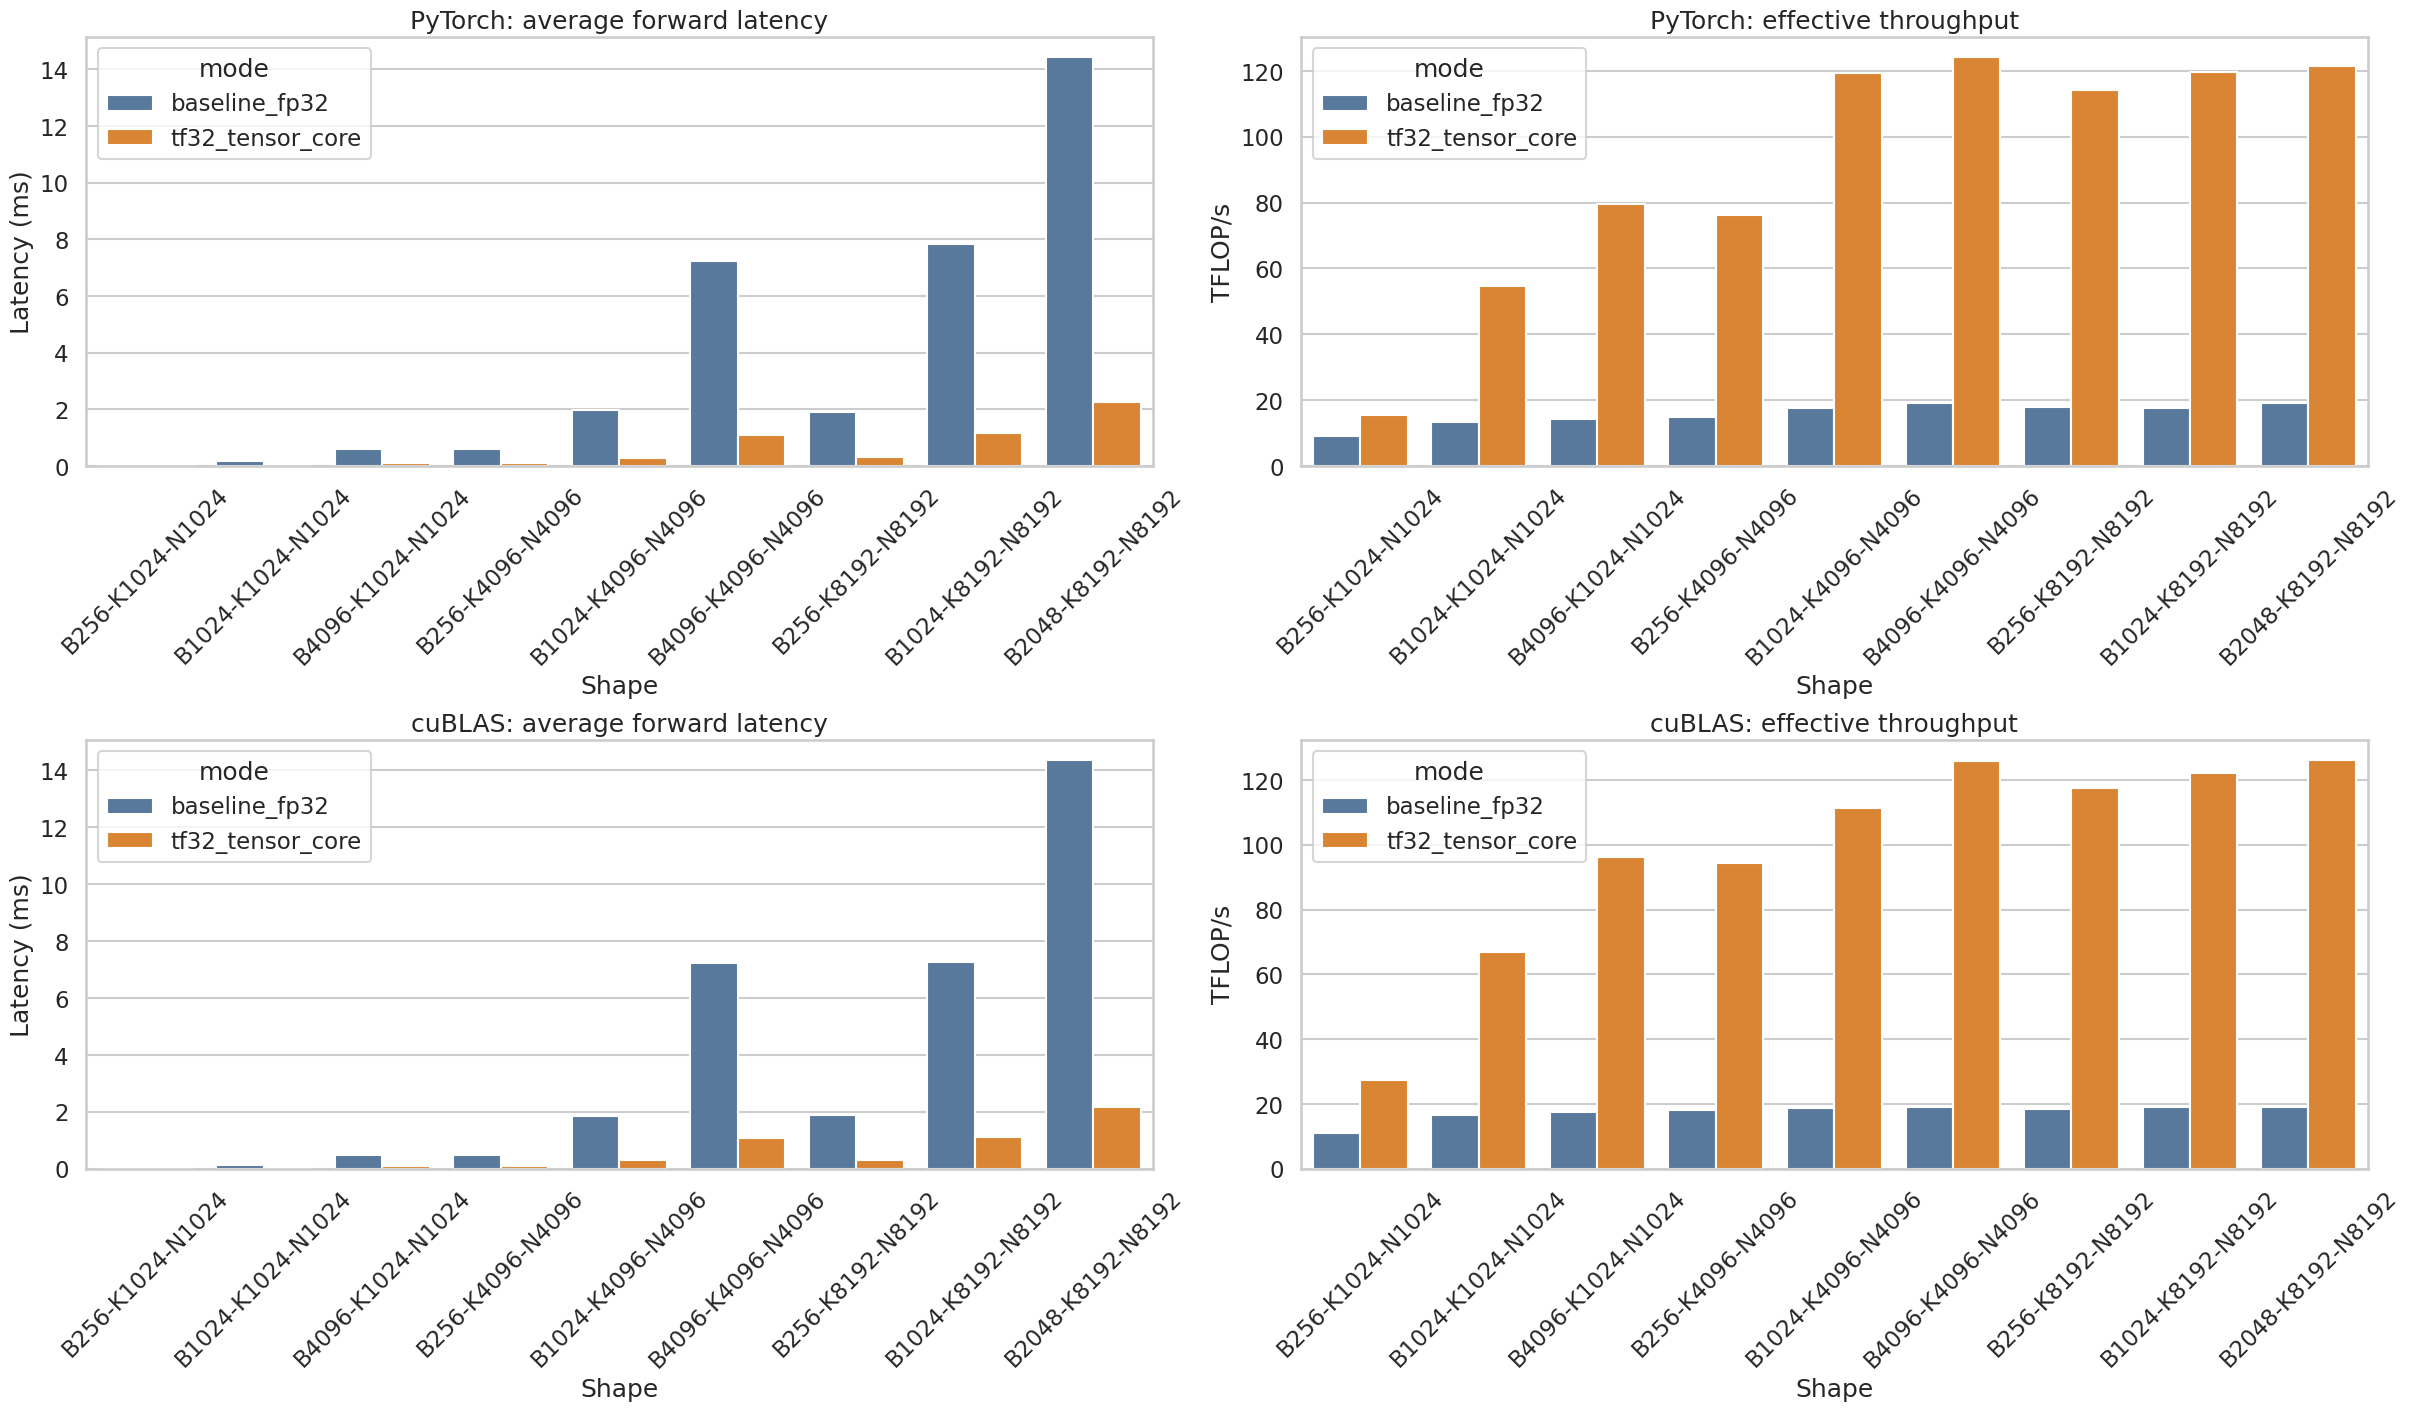

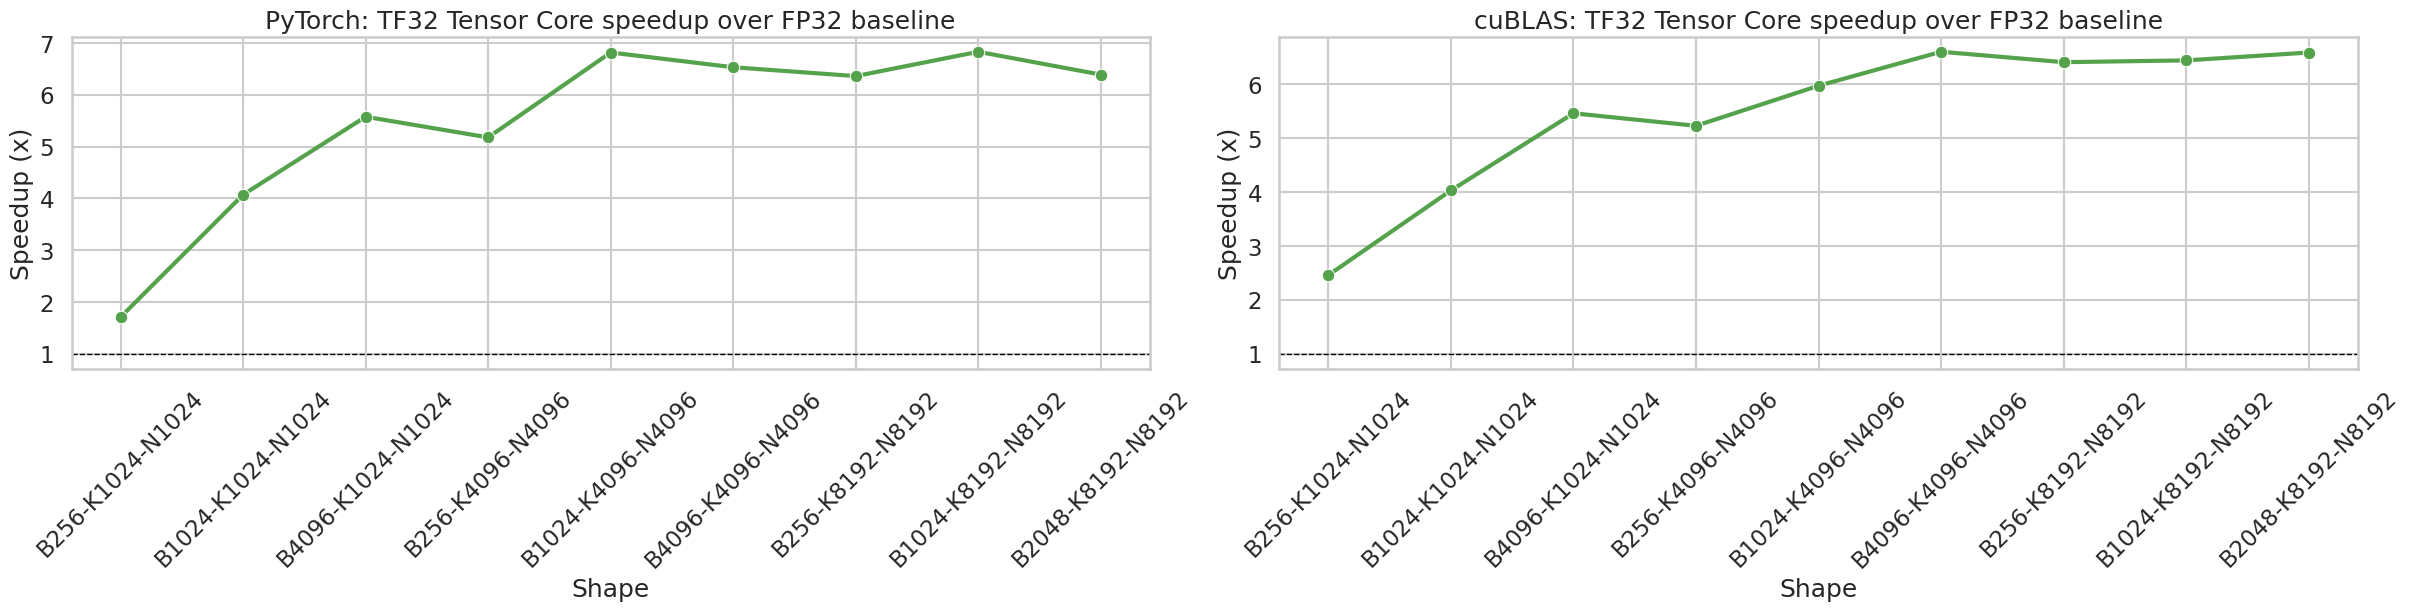

In [6]:
torch_df = pd.read_csv("torch_fc_results.csv")
cublas_df = pd.read_csv("cublas_fc_results.csv")

results = pd.concat([torch_df, cublas_df], ignore_index=True)
results["case"] = results.apply(
    lambda row: case_label(int(row["batch"]), int(row["in_features"]), int(row["out_features"])),
    axis=1,
)

order = [case_label(b, k, n) for b, k, n in SWEEP_CASES]

summary_rows = []
for backend in ["PyTorch", "cuBLAS"]:
    sub = results[results["backend"] == backend].copy()
    latency = sub.pivot(index="case", columns="mode", values="avg_ms").reindex(order)
    throughput = sub.pivot(index="case", columns="mode", values="tflops").reindex(order)
    speedup = latency["baseline_fp32"] / latency["tf32_tensor_core"]

    for case in order:
        summary_rows.append({
            "backend": backend,
            "case": case,
            "baseline_ms": latency.loc[case, "baseline_fp32"],
            "tf32_ms": latency.loc[case, "tf32_tensor_core"],
            "speedup_x": speedup.loc[case],
            "baseline_tflops": throughput.loc[case, "baseline_fp32"],
            "tf32_tflops": throughput.loc[case, "tf32_tensor_core"],
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("\nSpeedup summary by backend")
display(summary_df.groupby("backend")["speedup_x"].agg(["mean", "median", "max", "min"]))

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "baseline_fp32": "#4c78a8",
    "tf32_tensor_core": "#f58518",
}

fig, axes = plt.subplots(2, 2, figsize=(24, 14), constrained_layout=True)

for row_index, backend in enumerate(["PyTorch", "cuBLAS"]):
    sub = results[results["backend"] == backend].copy()
    sub["case"] = pd.Categorical(sub["case"], categories=order, ordered=True)

    sns.barplot(
        data=sub,
        x="case",
        y="avg_ms",
        hue="mode",
        palette=palette,
        ax=axes[row_index, 0],
    )
    axes[row_index, 0].set_title(f"{backend}: average forward latency")
    axes[row_index, 0].set_xlabel("Shape")
    axes[row_index, 0].set_ylabel("Latency (ms)")
    axes[row_index, 0].tick_params(axis="x", rotation=45)

    sns.barplot(
        data=sub,
        x="case",
        y="tflops",
        hue="mode",
        palette=palette,
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"{backend}: effective throughput")
    axes[row_index, 1].set_xlabel("Shape")
    axes[row_index, 1].set_ylabel("TFLOP/s")
    axes[row_index, 1].tick_params(axis="x", rotation=45)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)

for ax, backend in zip(axes, ["PyTorch", "cuBLAS"]):
    sub = results[results["backend"] == backend].copy()
    latency = sub.pivot(index="case", columns="mode", values="avg_ms").reindex(order)
    speedup = latency["baseline_fp32"] / latency["tf32_tensor_core"]

    sns.lineplot(
        x=speedup.index,
        y=speedup.values,
        marker="o",
        linewidth=3,
        color="#54a24b",
        ax=ax,
    )
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{backend}: TF32 Tensor Core speedup over FP32 baseline")
    ax.set_xlabel("Shape")
    ax.set_ylabel("Speedup (x)")
    ax.tick_params(axis="x", rotation=45)

plt.show()

#Section 7: Optional numerical-difference check for PyTorch

In [7]:
batch, in_features, out_features = SWEEP_CASES[-2]

torch.manual_seed(1234)
torch.cuda.manual_seed_all(1234)

x = torch.randn(batch, in_features, device=device, dtype=torch.float32)
model = FCModel(in_features, out_features).eval()

configure_torch_mode(False)
with torch.inference_mode():
    y_fp32 = model(x)
torch.cuda.synchronize()

configure_torch_mode(True)
with torch.inference_mode():
    y_tf32 = model(x)
torch.cuda.synchronize()

abs_diff = (y_fp32 - y_tf32).abs()
rel_diff = abs_diff / y_fp32.abs().clamp_min(1e-6)

print("Case:", case_label(batch, in_features, out_features))
print("Max abs diff :", abs_diff.max().item())
print("Mean abs diff:", abs_diff.mean().item())
print("Max rel diff :", rel_diff.max().item())
print("Mean rel diff:", rel_diff.mean().item())

Case: B1024-K8192-N8192
Max abs diff : 0.0028147753328084946
Mean abs diff: 0.00042449048487469554
Max rel diff : 758.1494750976562
Mean rel diff: 0.0029187567997723818
